In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import datetime

In [12]:
def get_save_name(county: str):
    return "_".join(county.split(" ")).lower()

In [32]:
def recover_proper_name(county_save_name: str):
    words = county_save_name.split("_")
    words = [word.capitalize() for word in words]
    return " ".join(words)

In [33]:
recover_proper_name("san_francisco")

'San Francisco'

In [ ]:
queer_areas = {
    "San Francisco": {
        "state": "California",
        "neighboring_counties": ['Alameda', 'Contra Costa', 'Marin', 'Napa', 'San Mateo', 'Santa Clara', 'Solano', 'Sonoma']
    },
    "Multnomah": {
        "state": "Oregon",
        "neighboring_counties": ['Columbia', 'Clark', 'Skamania', 'Hood River', 'Clackamas', 'Washington']
    },
    "King": {
        "state": "Washington",
        "neighboring_counties": ['Snohomish', 'Washington', 'Kitsap', 'Kittitas', 'Yakima', 'Pierce', 'Chelan']
    }
}

In [24]:
data = pd.read_csv("us-counties.csv", delimiter=',')

In [25]:
start_date = pd.to_datetime("2020-03-10")
end_date = pd.to_datetime("2022-03-10")
weekly_dates = pd.date_range(start=start_date, end=end_date, freq='W') - pd.DateOffset(days=5) # subtract 5 days to get to weekday of 3/10/2020; Tuesday

def save_data(parent_folder: str, county: str, state: str):
    global data
    global start_date
    global end_date
    global weekly_dates
        
    area_data = data[(data['county'] == county) & (data['state'] == state)]
    area_data['date'] = pd.to_datetime(area_data['date'])
    area_data = area_data[(area_data['date'] >= start_date) & (area_data['date'] <= end_date)]
    area_data['delta_cases'] = area_data['cases'].diff().fillna(0)
    weekly_area_data = area_data[area_data['date'].isin(weekly_dates)]
    weekly_area_data['delta_cases'] = weekly_area_data['cases'].diff().fillna(0)
    if not os.path.exists(f"{parent_folder}/{county}"):
        os.mkdir(f"{parent_folder}/{county}")
    area_data.to_csv(f"{parent_folder}/{county}/{county}_daily.csv", index=False)
    weekly_area_data.to_csv(f"{parent_folder}/{county}/{county}_weekly.csv", index=False)

In [26]:
queer_areas = {
    "San Francisco": {
        "state": "California",
        "neighboring_counties": ['Alameda', 'Contra Costa', 'Marin', 'Napa', 'San Mateo', 'Santa Clara', 'Solano', 'Sonoma']
    },
    "Multnomah": {
        "state": "Oregon",
        "neighboring_counties": ['Columbia', 'Clark', 'Skamania', 'Hood River', 'Clackamas', 'Washington']
    },
    "King": {
        "state": "Washington",
        "neighboring_counties": ['Snohomish', 'Washington', 'Kitsap', 'Kittitas', 'Yakima', 'Pierce', 'Chelan']
    }
}

In [27]:
for county, info in queer_areas.items():
    county_save_name = get_save_name(county)
    save_data("queer_areas", county_save_name, info['state'])
    for neighbor in info['neighboring_counties']:
        if not os.path.exists(f"queer_areas/{county_save_name}/neighbors"):
            os.mkdir(f"queer_areas/{county_save_name}/neighbors")
        save_data(f"queer_areas/{county_save_name}/neighbors", get_save_name(neighbor), info['state'])

In [34]:
def plot_cases_over_time(parent_folder: str, county: str, state: str, weekly: bool=False):
    data_sample = "daily"
    if weekly:
        data_sample = "weekly"
        
    area_data = pd.read_csv(f"{parent_folder}/{county}/{county}_{data_sample}.csv", delimiter=',')
    area_data['date'] = pd.to_datetime(area_data['date'])
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(area_data['date'], area_data['delta_cases'])
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Every 3 months
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format as 'Jan 2020', etc.
    ax.set_xlabel("Date")
    ax.set_ylabel(f"{data_sample.capitalize()} new COVID Cases")
    ax.set_title(f"{data_sample.capitalize()} new COVID Cases for {recover_proper_name(county)} County, {state}")
    plt.savefig(f"{parent_folder}/{county}/new_cases_{county}_{data_sample}.png")

C:\Users\cgera\AppData\Local\Temp\ipykernel_12616\478429302.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 5))


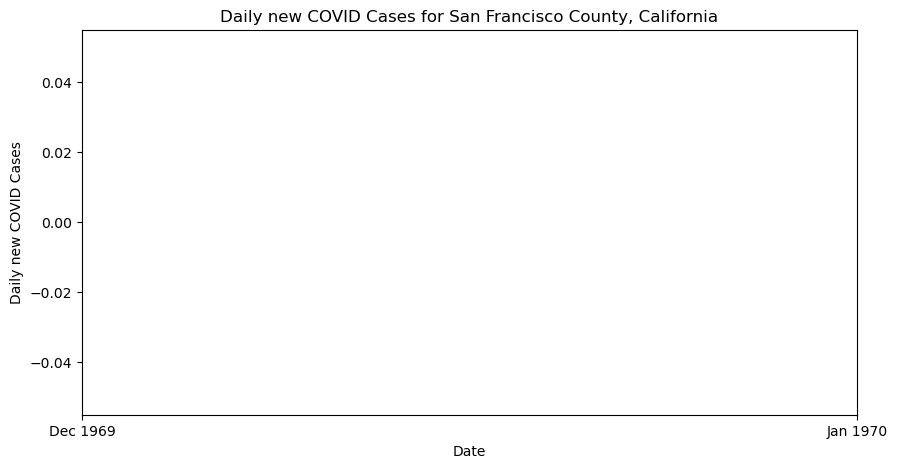

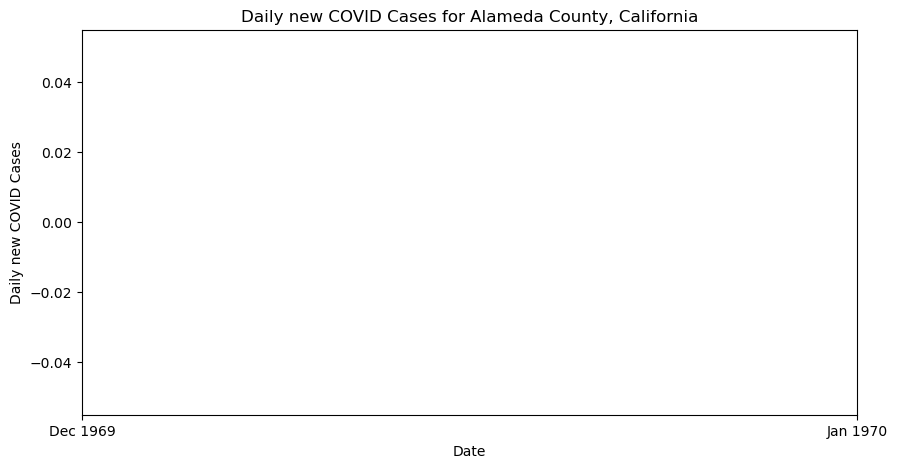

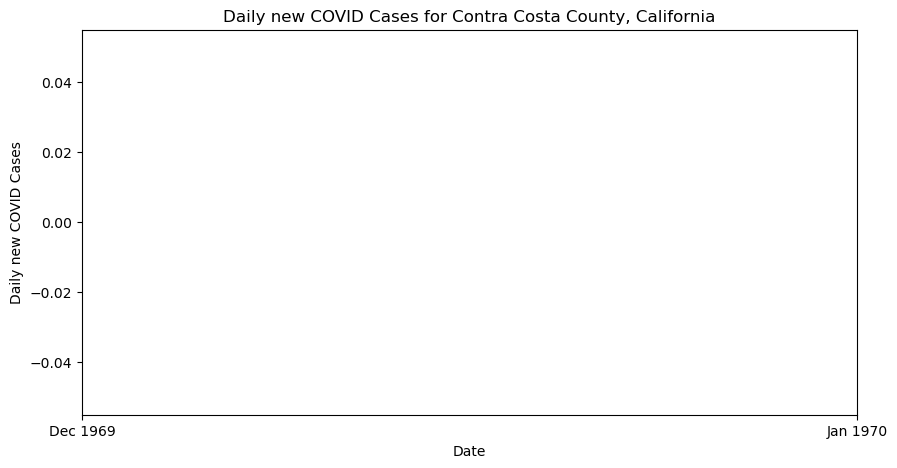

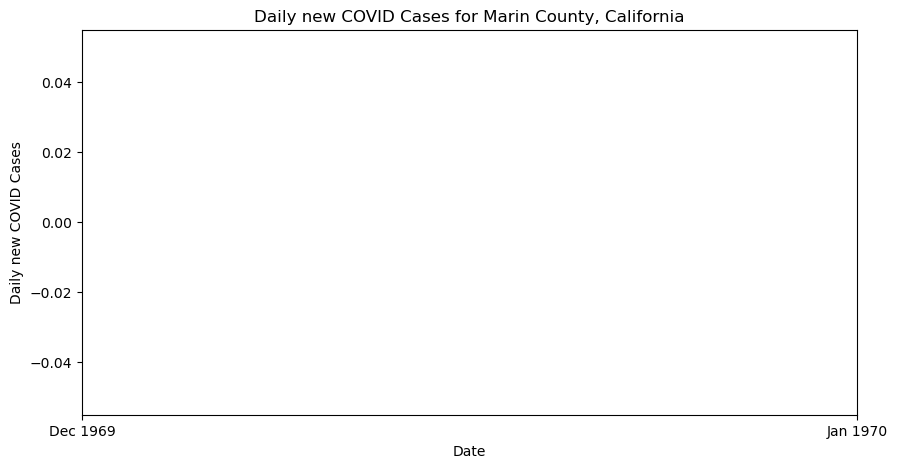

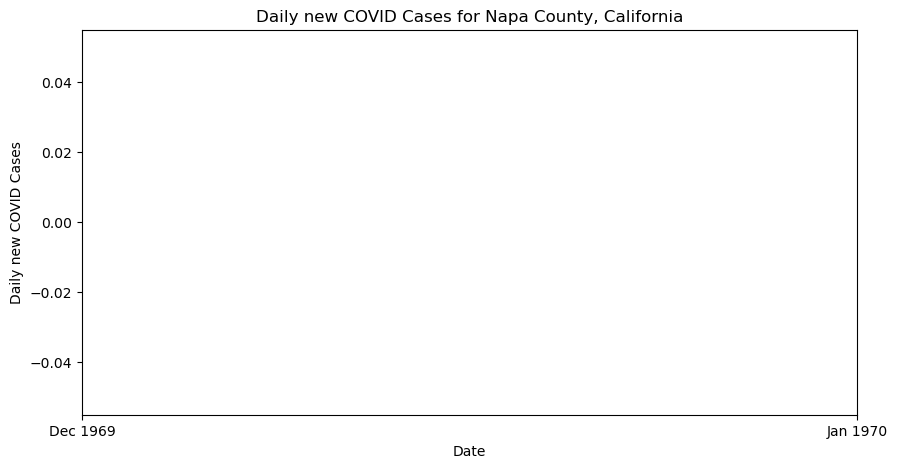

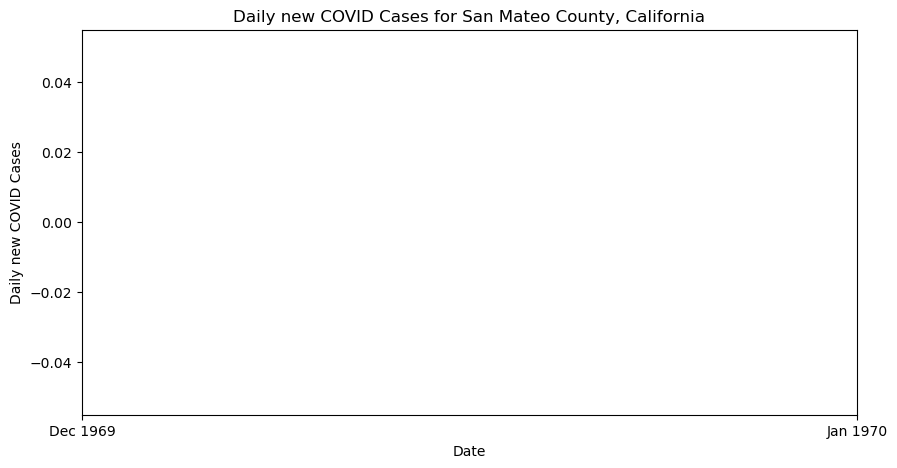

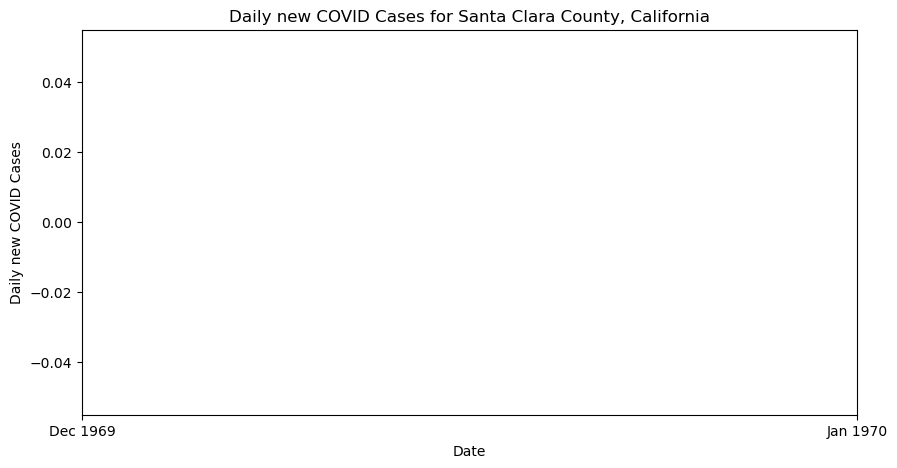

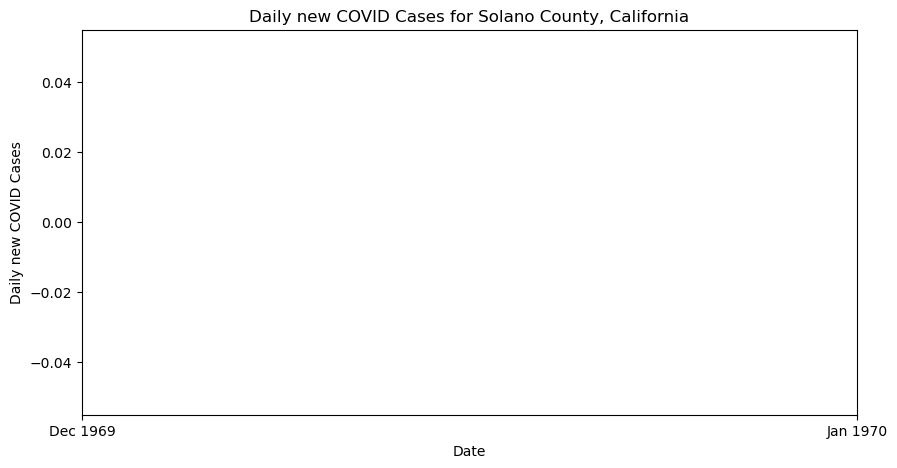

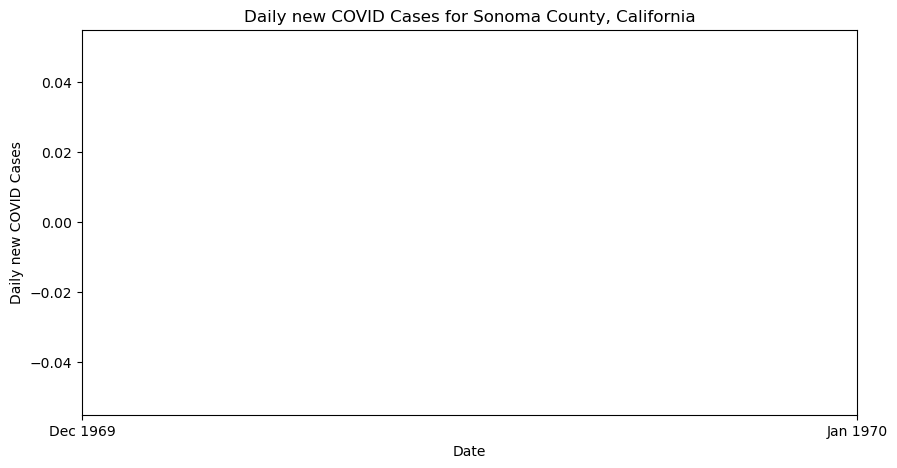

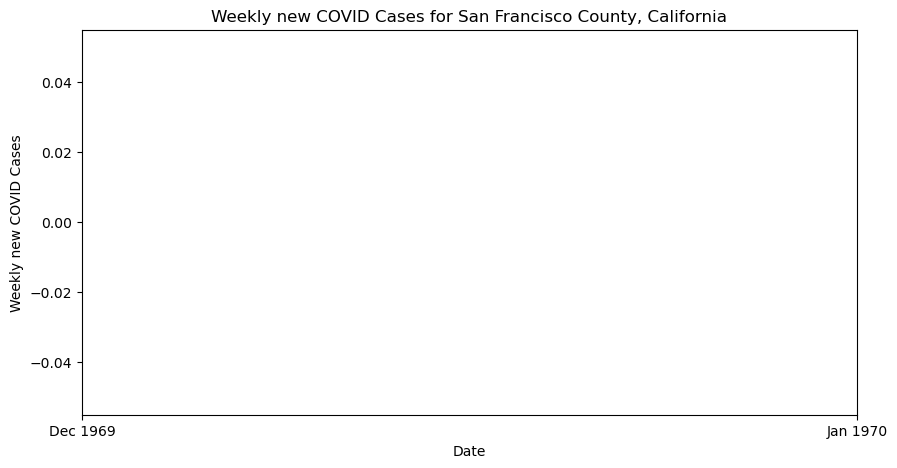

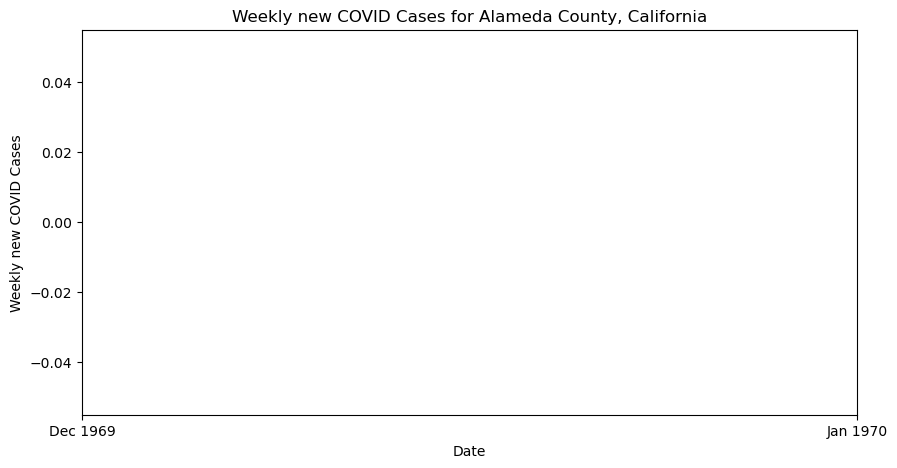

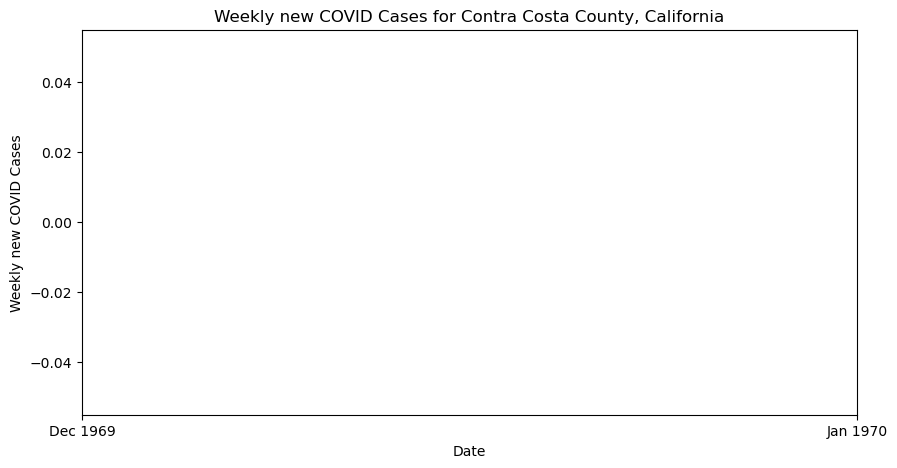

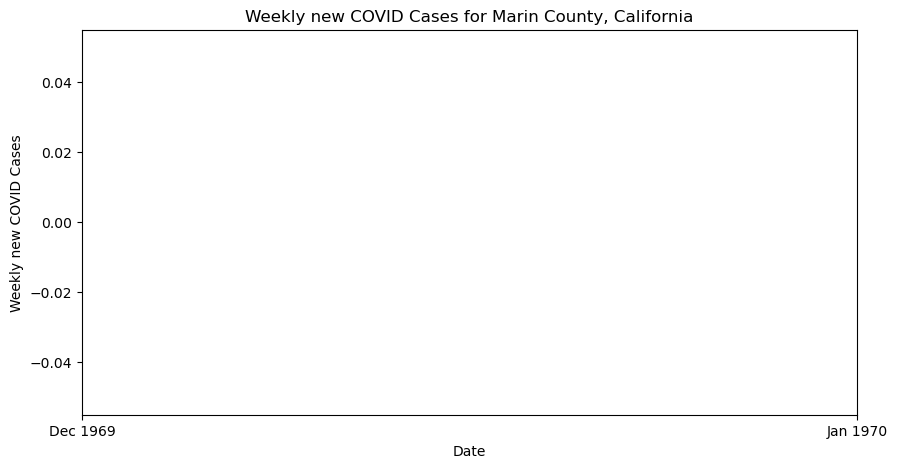

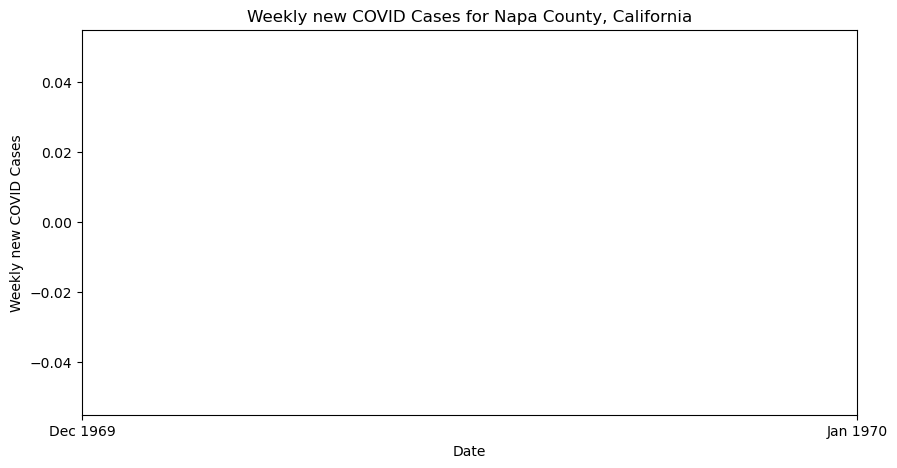

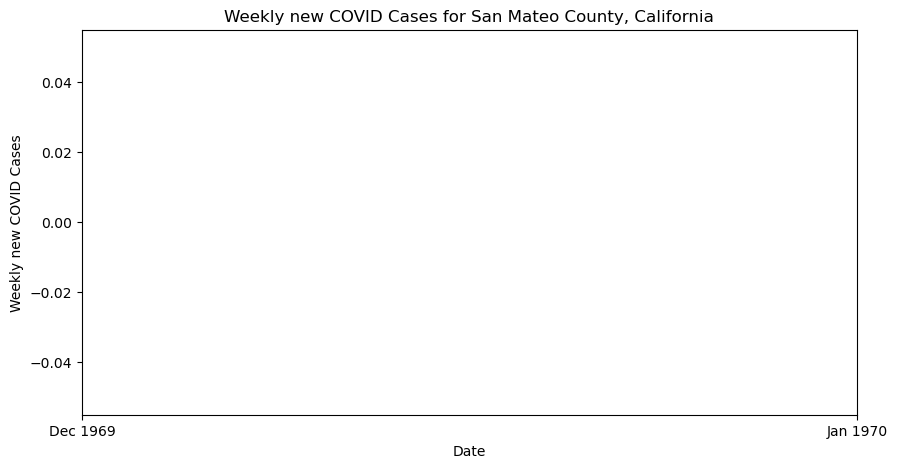

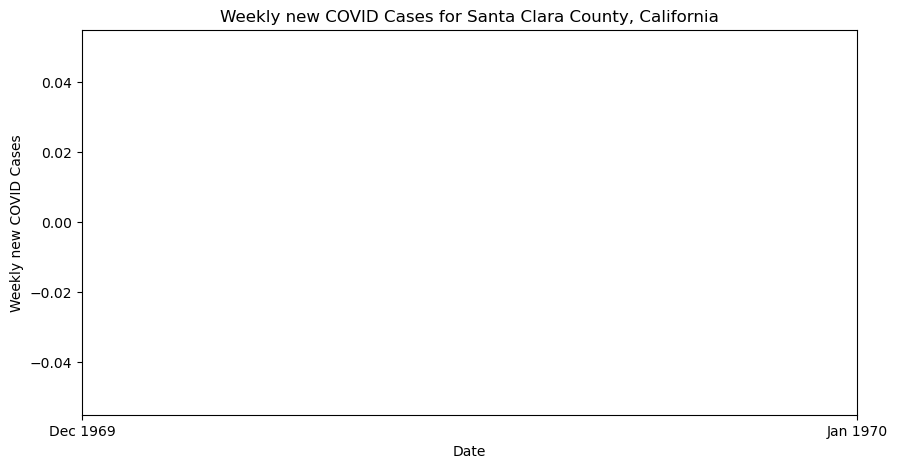

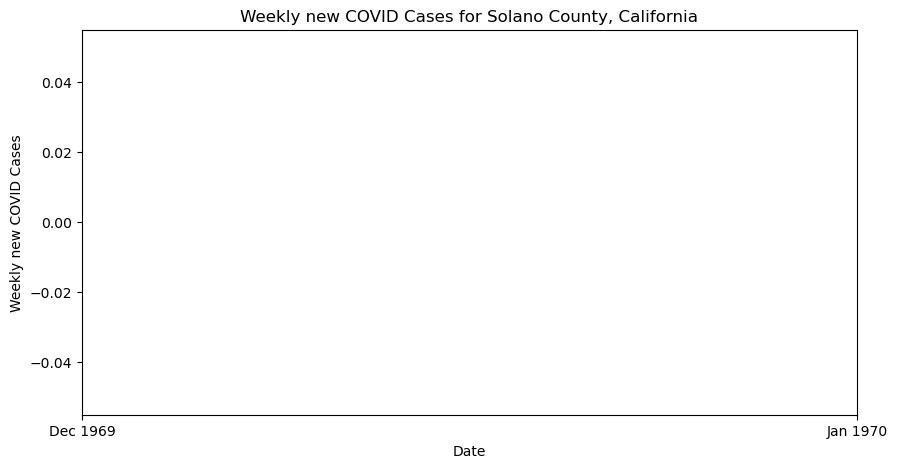

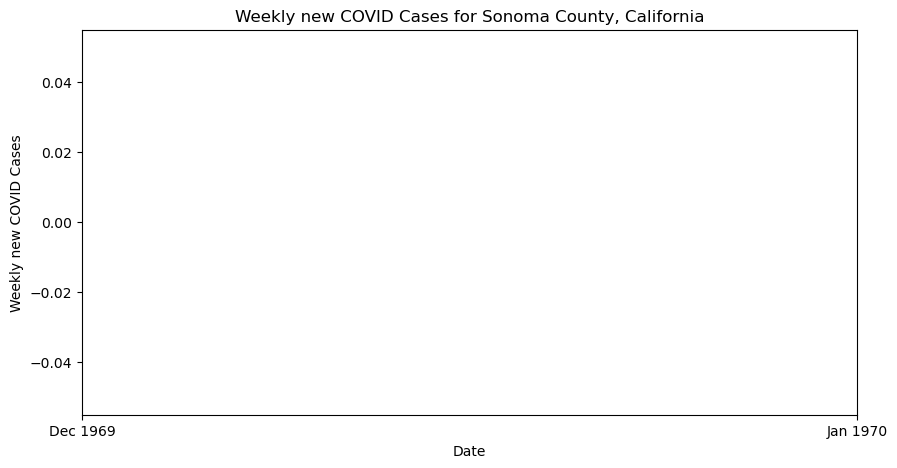

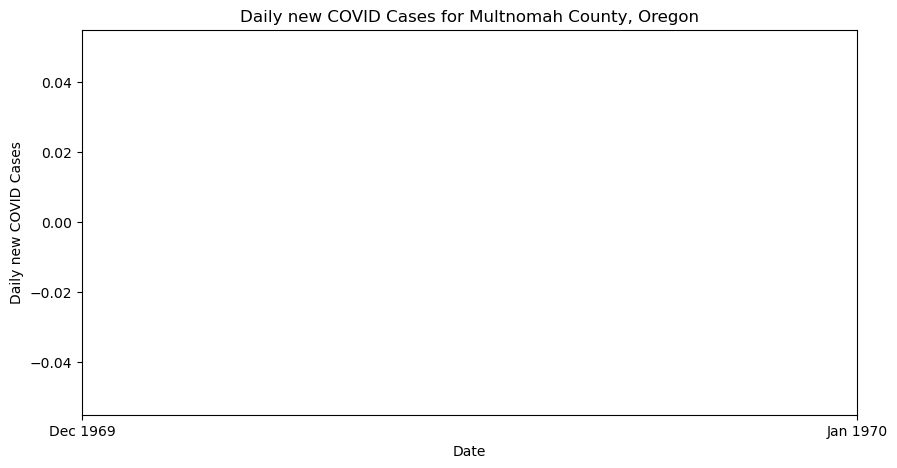

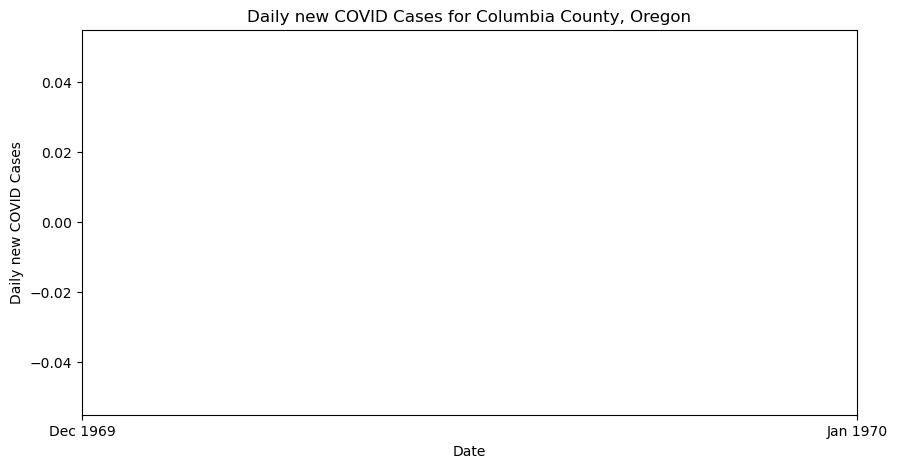

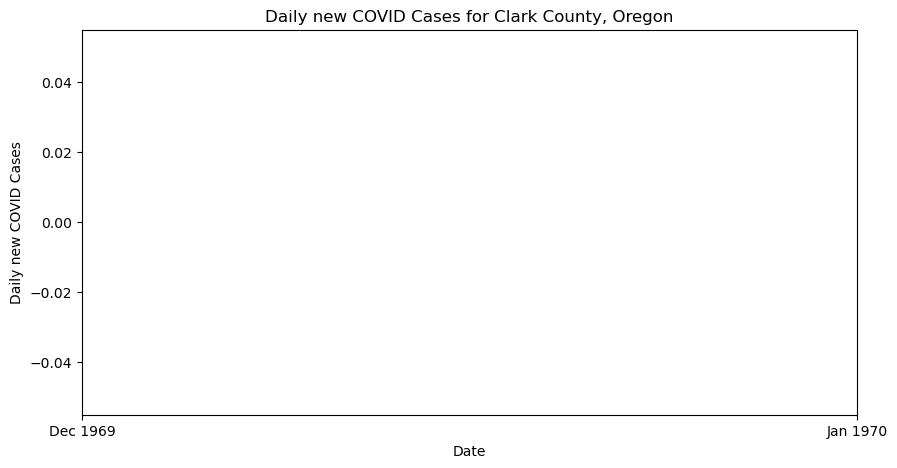

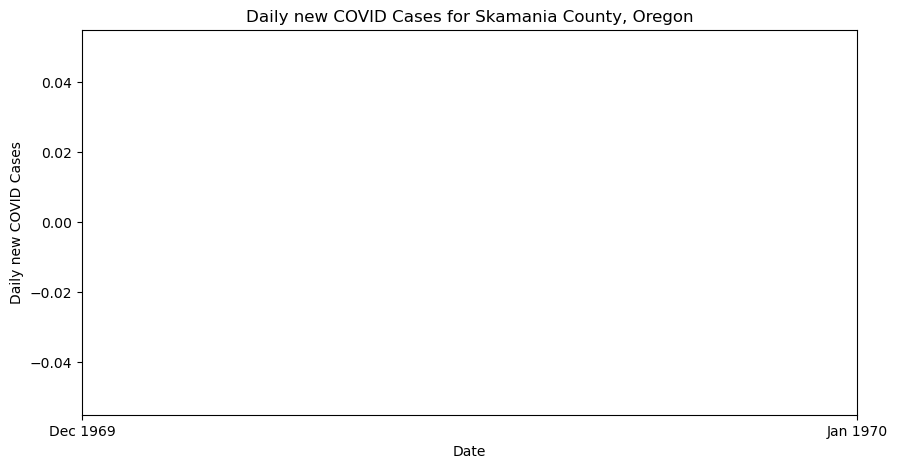

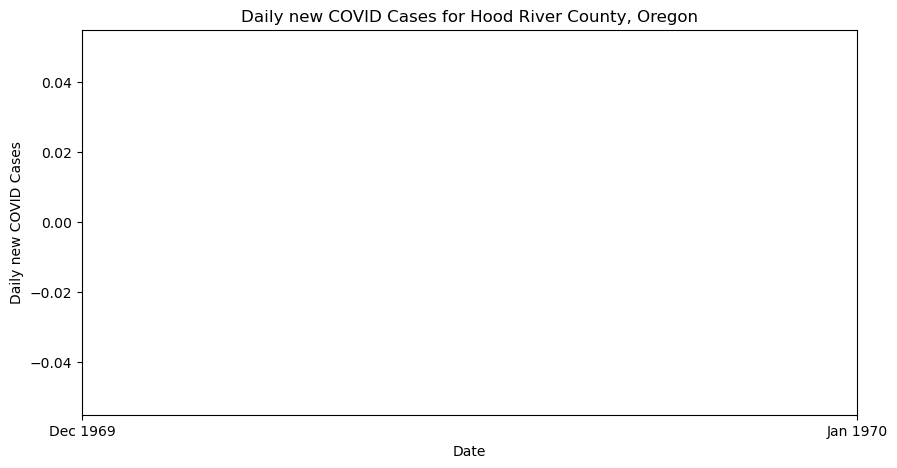

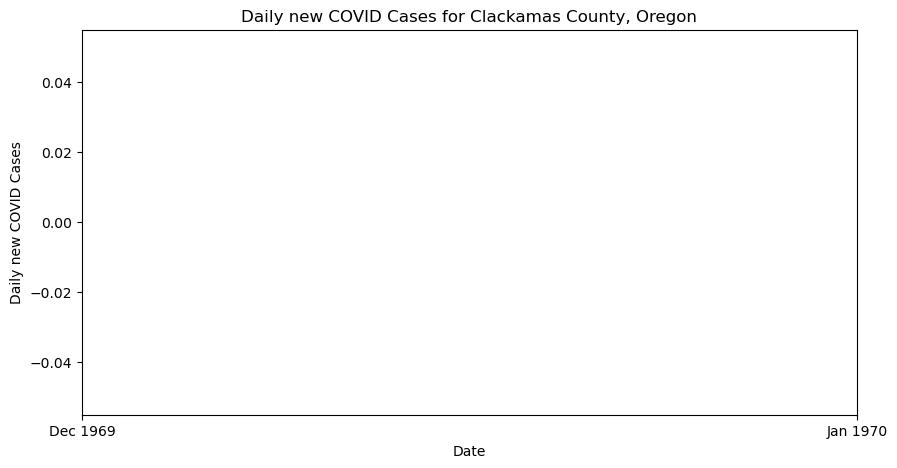

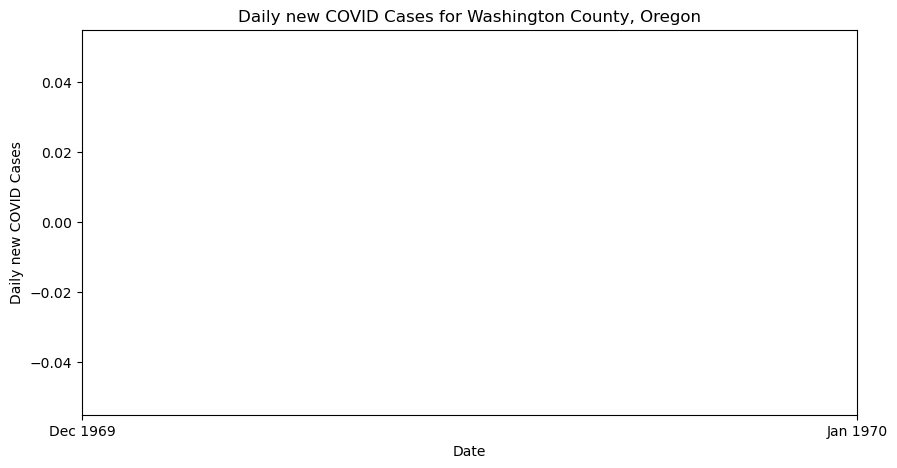

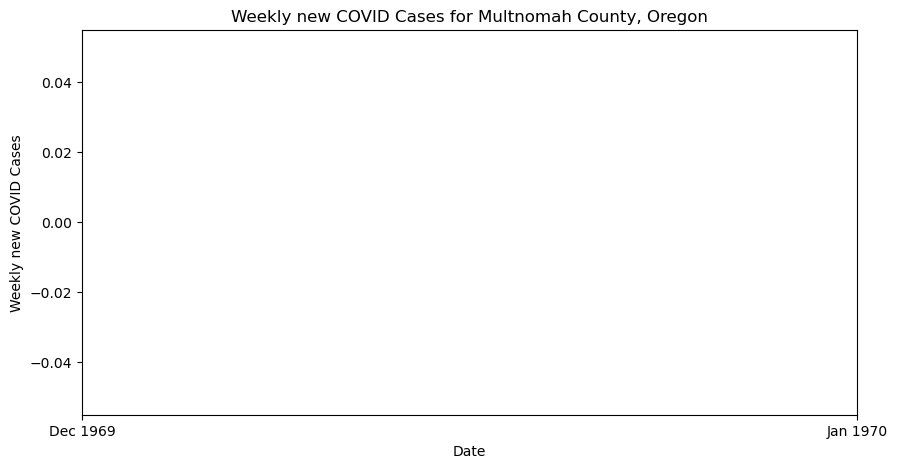

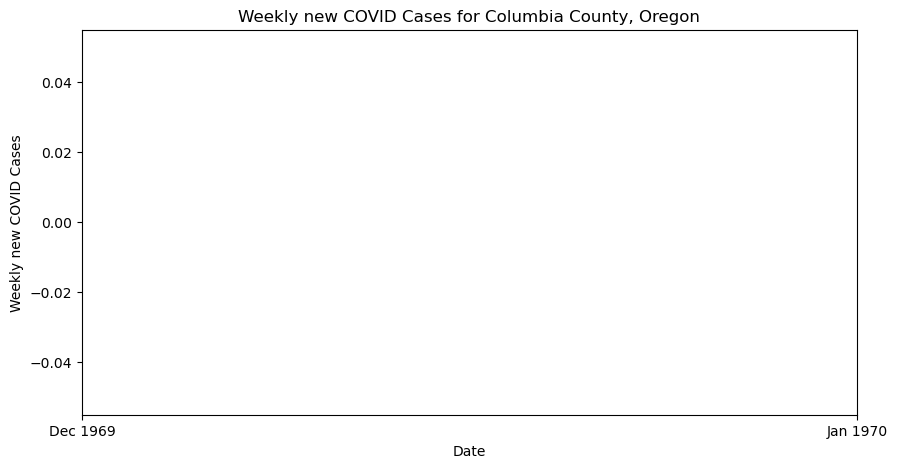

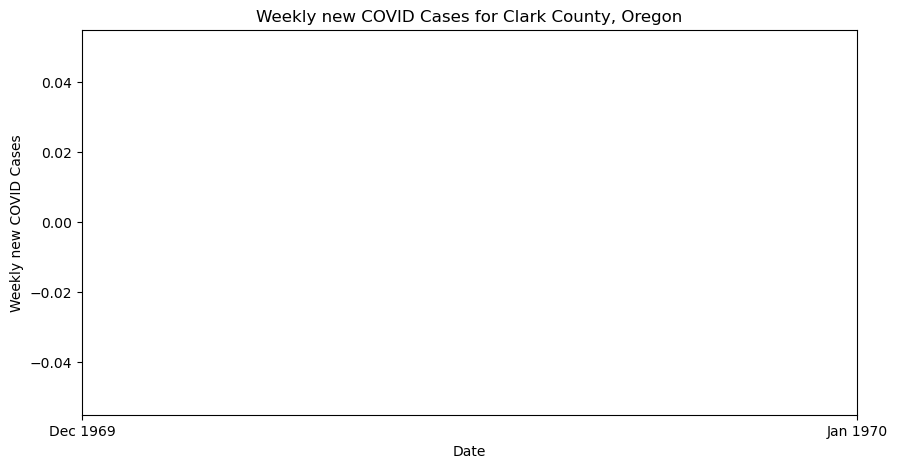

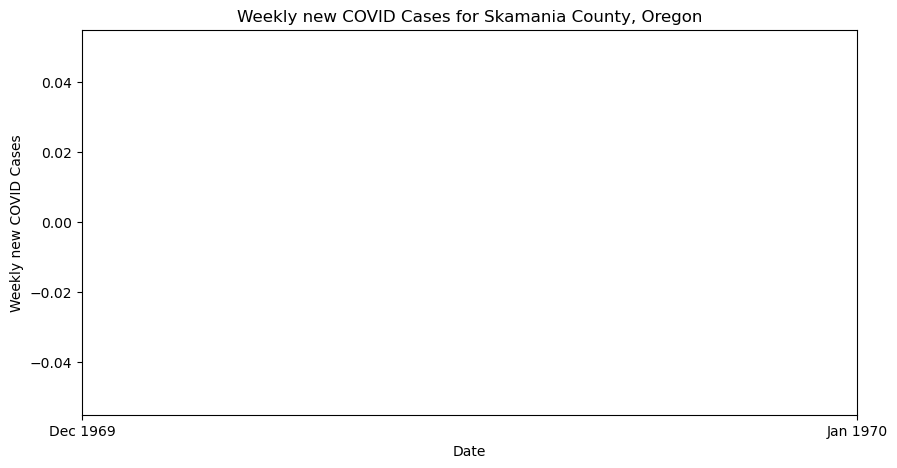

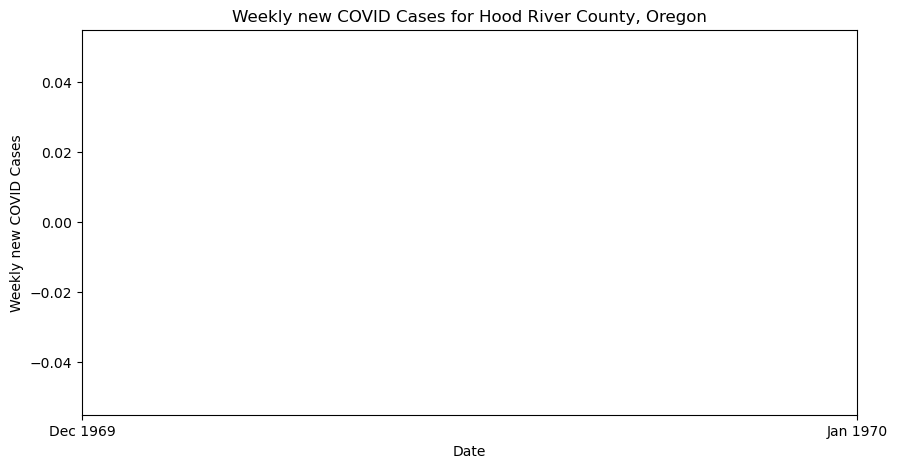

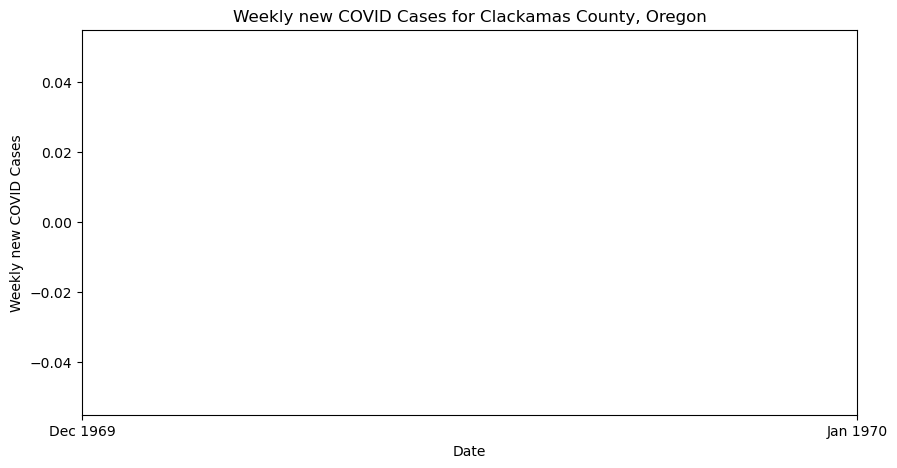

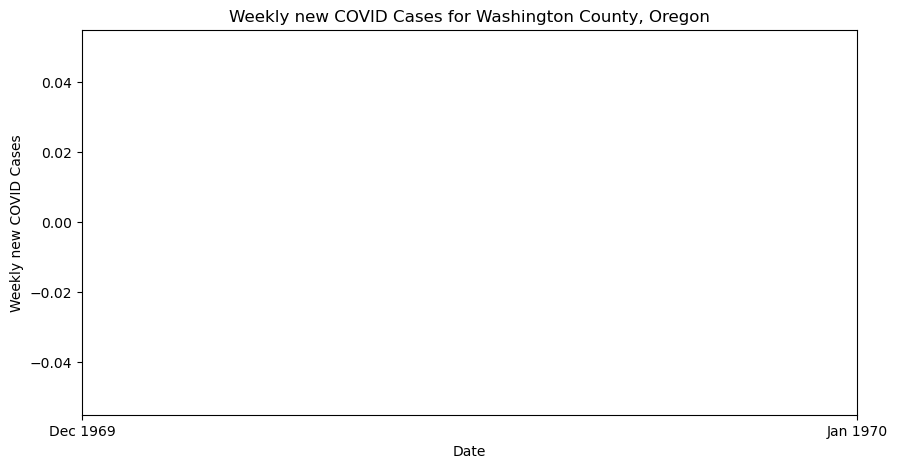

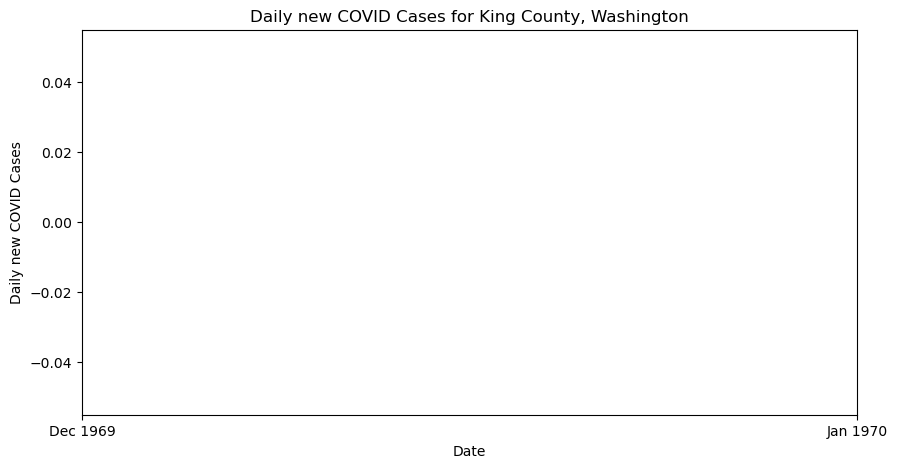

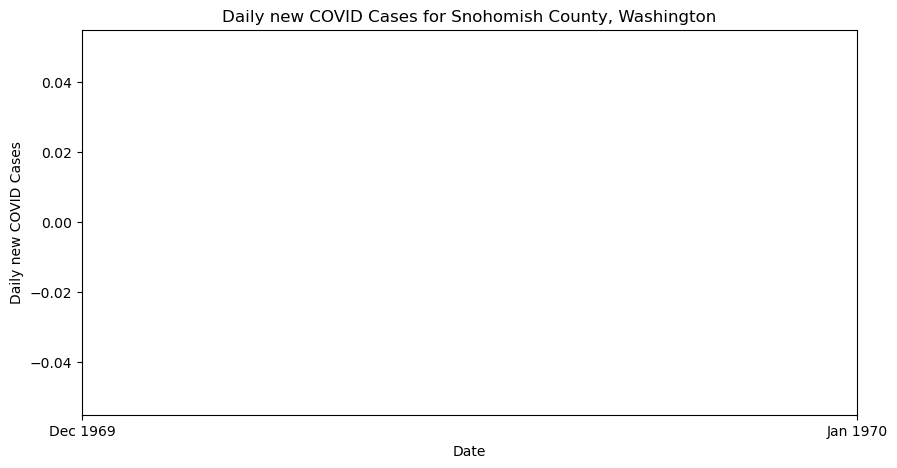

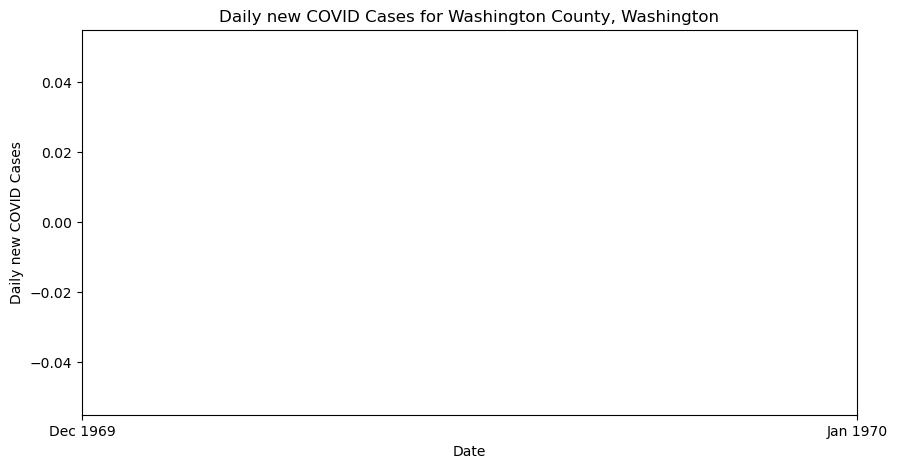

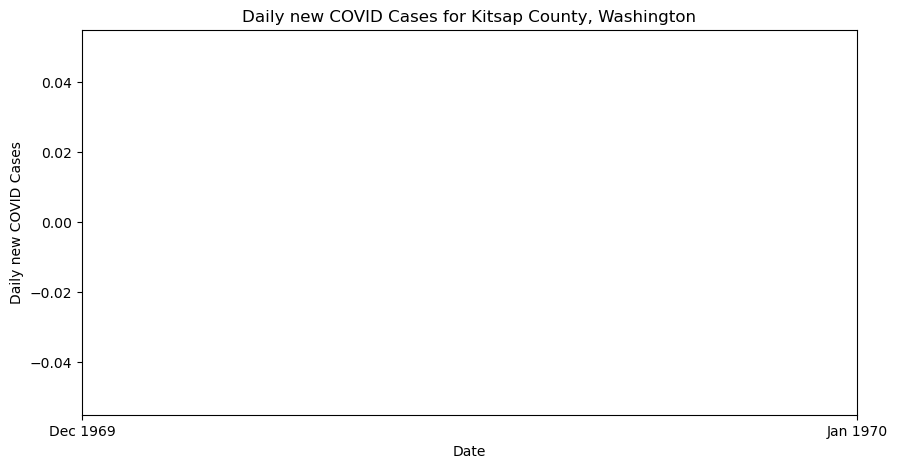

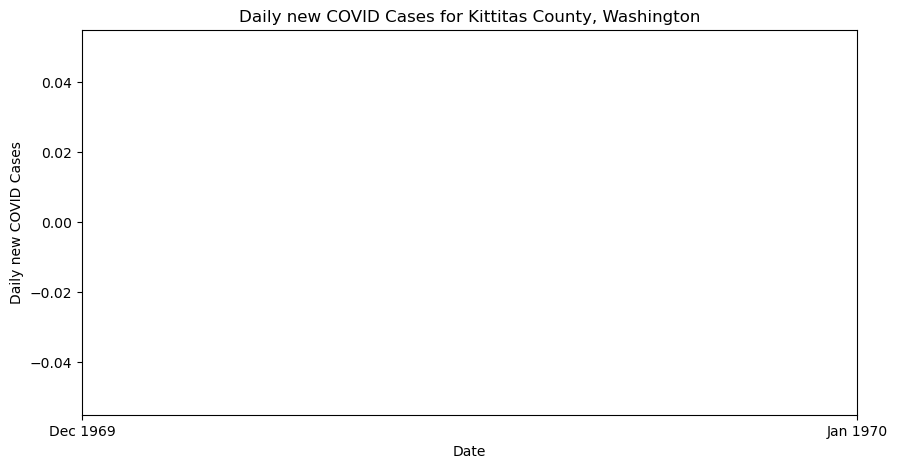

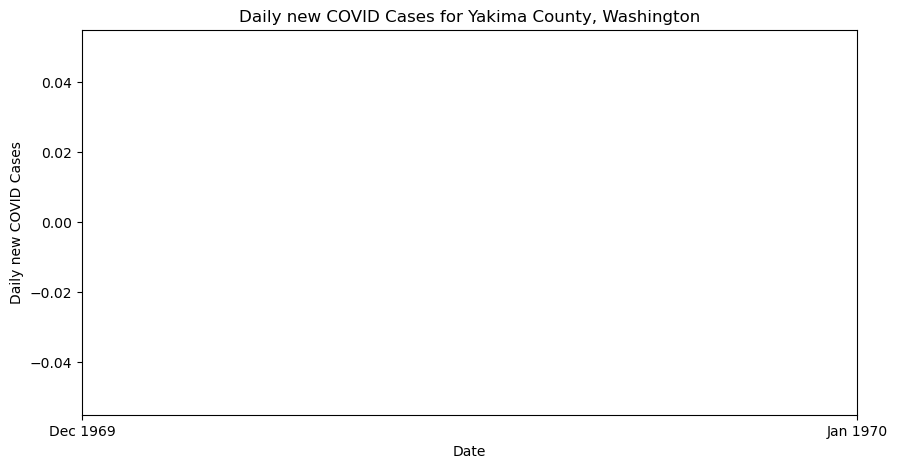

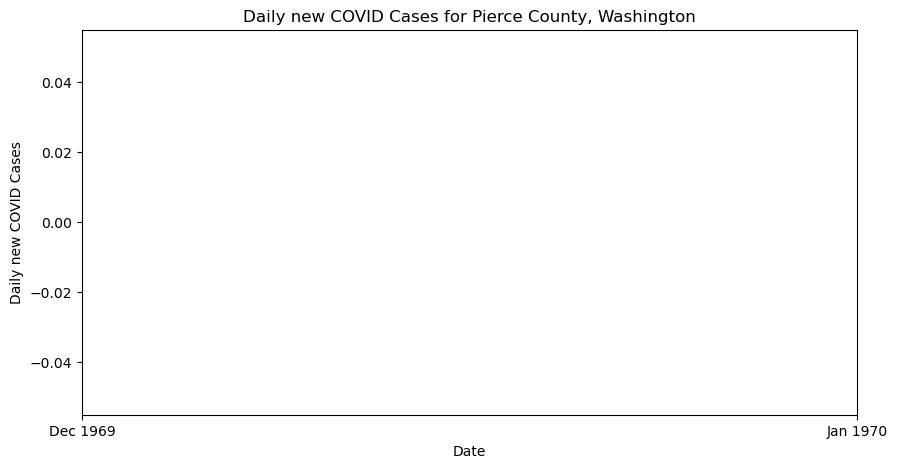

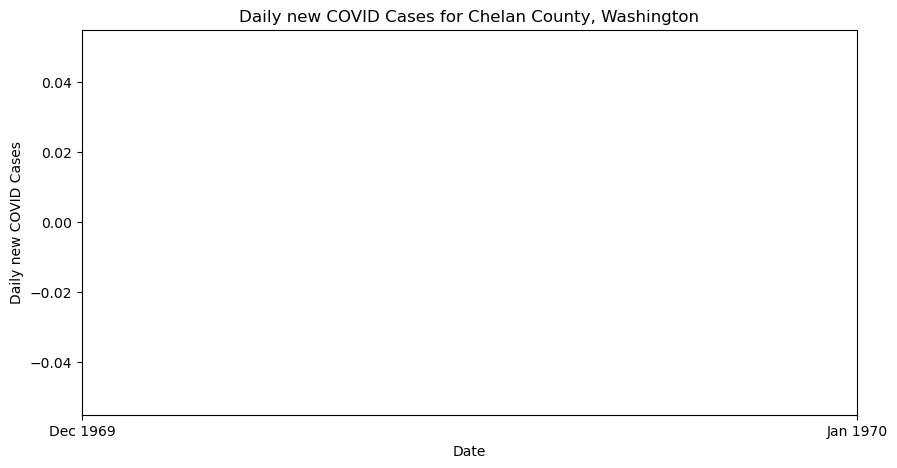

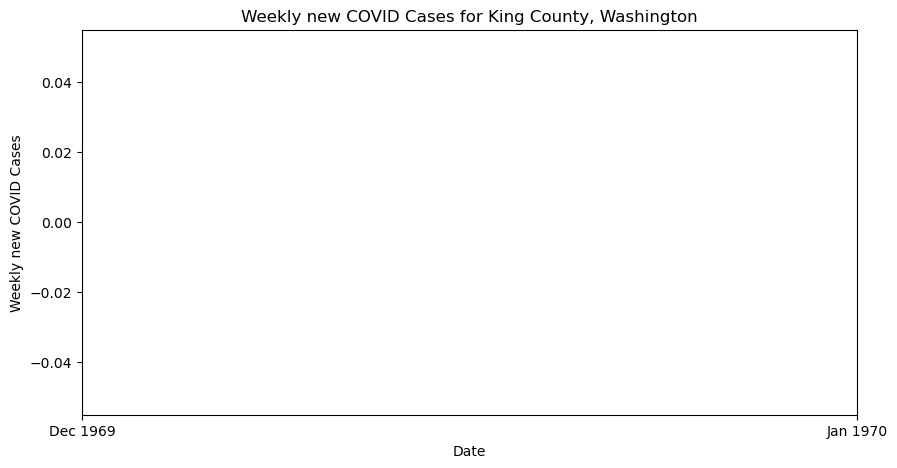

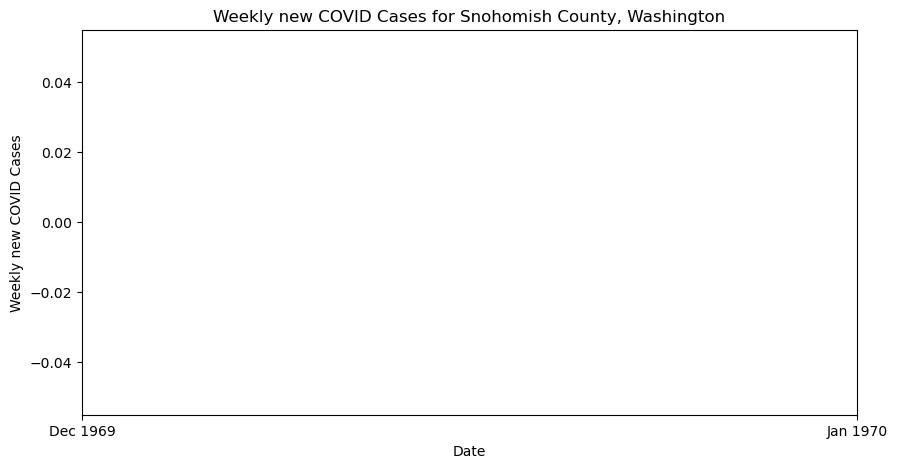

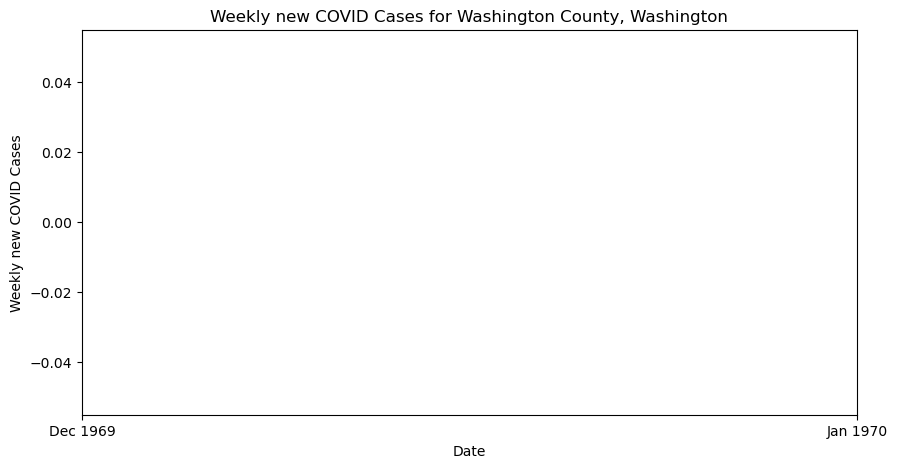

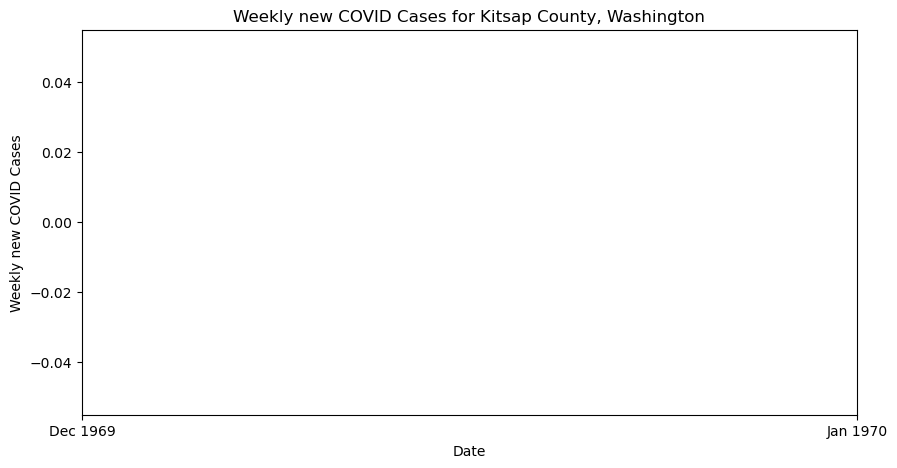

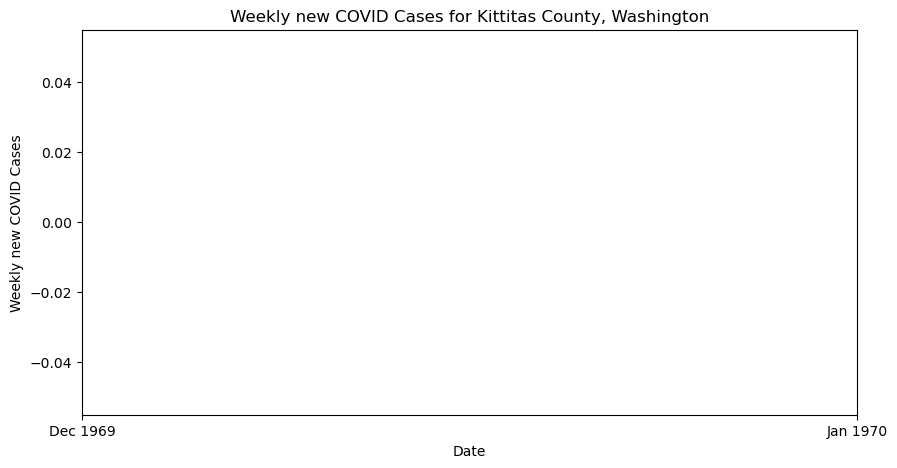

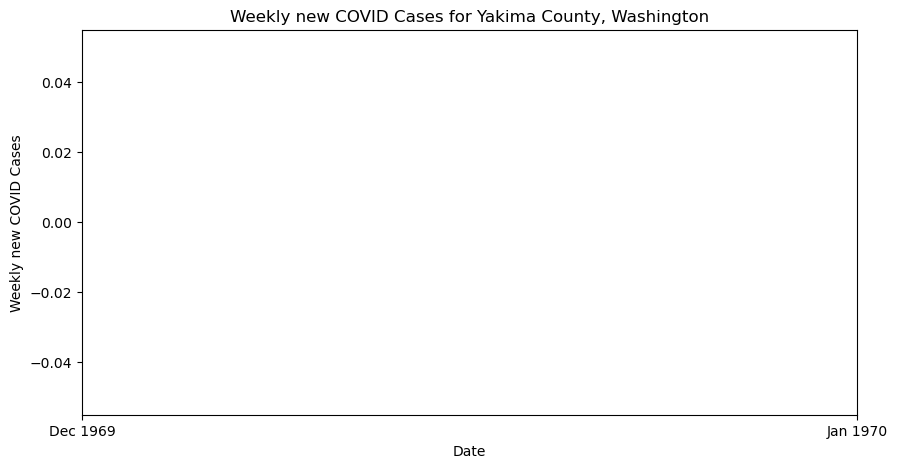

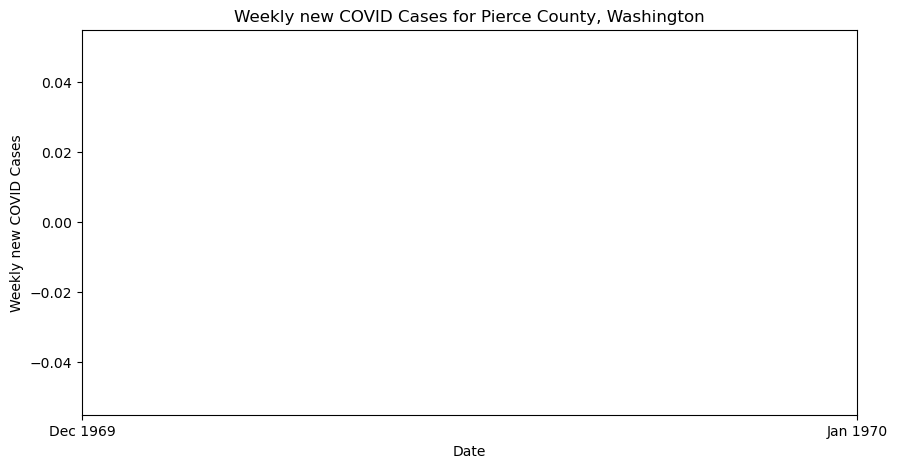

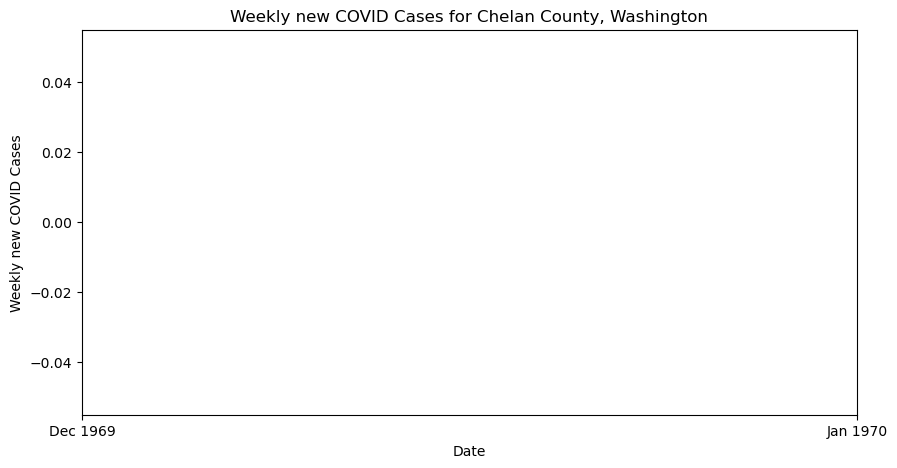

In [40]:

for county, info in queer_areas.items():
    county_save_name = get_save_name(county)
    for weekly in [False, True]:
        plot_cases_over_time("queer_areas", county_save_name, info['state'], weekly)
        for neighbor in info['neighboring_counties']:
            neighbor_save_name = get_save_name(neighbor)
            plot_cases_over_time(f"queer_areas/{county_save_name}/neighbors", neighbor_save_name, info['state'], weekly)
